In [1]:
from utils import *
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

In [5]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [9]:
N_FEATURES = 16
N_CONTEXT = 42

## Linear Regression

Simple population-level linear regression model. The patient is not considered.

In [6]:
X, Y, C = load_parkinsons_data()
model = LinearRegression().fit(X, Y)
y_pred = model.predict(X)
print("Loss:\n", np.mean((y_pred - Y)**2))
print("RMSD:\n", np.sqrt(np.mean((y_pred - Y)**2)))

Loss:
 0.899563
RMSD:
 0.94845295


Next, we try learning a separate linear regression model for each patient. Notice the loss is much better.

In [48]:
X, Y, C = load_parkinsons_data()
model = ContextLinearRegression().fit(X, Y, C)
y_pred = model.predict(X, C)
print("Loss:\n", np.mean((y_pred - Y)**2))
print("RMSD:\n", np.sqrt(np.mean((y_pred - Y)**2)))

Loss:
 0.09950164509373242
RMSD:
 0.3154388135498427


## Multilayer Perceptron


In [47]:

model = NeuralNetwork(dim_in=N_FEATURES, dim_out=1, dim_hidden=10, n_hidden=1).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

full_dataset = ParkinsonsDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 1.332816  [   50/ 4700]
loss: 1.047915  [  550/ 4700]
loss: 0.879007  [ 1050/ 4700]
loss: 0.862137  [ 1550/ 4700]
loss: 1.011108  [ 2050/ 4700]
loss: 0.985285  [ 2550/ 4700]
loss: 1.359217  [ 3050/ 4700]
loss: 0.979912  [ 3550/ 4700]
loss: 0.962650  [ 4050/ 4700]
loss: 1.057090  [ 4550/ 4700]
Test Error: 
 Avg loss: 1.055693 

Epoch 2
-------------------------------
loss: 1.202963  [   50/ 4700]
loss: 0.976634  [  550/ 4700]
loss: 0.820502  [ 1050/ 4700]
loss: 0.846207  [ 1550/ 4700]
loss: 0.962500  [ 2050/ 4700]
loss: 0.952469  [ 2550/ 4700]
loss: 1.330790  [ 3050/ 4700]
loss: 0.974256  [ 3550/ 4700]
loss: 0.942424  [ 4050/ 4700]
loss: 1.014819  [ 4550/ 4700]
Test Error: 
 Avg loss: 1.029323 

Epoch 3
-------------------------------
loss: 1.155777  [   50/ 4700]
loss: 0.944267  [  550/ 4700]
loss: 0.794240  [ 1050/ 4700]
loss: 0.837954  [ 1550/ 4700]
loss: 0.947748  [ 2050/ 4700]
loss: 0.933649  [ 2550/ 4700]
loss: 1.315753  [ 3050/ 4700]


## Context-Sensitive Network
The task is one-hot-encoded and appended to the input.

In [10]:
model = NeuralNetwork(dim_in=N_FEATURES + N_CONTEXT, dim_out=1, dim_hidden=300, n_hidden=3).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

full_dataset = ContextSensitiveParkinsonsDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 1.027899  [   50/ 4700]
loss: 1.066585  [  550/ 4700]
loss: 0.984373  [ 1050/ 4700]
loss: 0.782868  [ 1550/ 4700]
loss: 1.140556  [ 2050/ 4700]
loss: 0.911400  [ 2550/ 4700]
loss: 0.642928  [ 3050/ 4700]
loss: 0.863409  [ 3550/ 4700]
loss: 1.015842  [ 4050/ 4700]
loss: 1.487225  [ 4550/ 4700]
Test Error: 
 Avg loss: 1.003001 

Epoch 2
-------------------------------
loss: 1.025496  [   50/ 4700]
loss: 1.062028  [  550/ 4700]
loss: 0.981487  [ 1050/ 4700]
loss: 0.777744  [ 1550/ 4700]
loss: 1.132654  [ 2050/ 4700]
loss: 0.902772  [ 2550/ 4700]
loss: 0.638971  [ 3050/ 4700]
loss: 0.859130  [ 3550/ 4700]
loss: 1.010169  [ 4050/ 4700]
loss: 1.474823  [ 4550/ 4700]
Test Error: 
 Avg loss: 1.000633 

Epoch 3
-------------------------------
loss: 1.023590  [   50/ 4700]
loss: 1.058583  [  550/ 4700]
loss: 0.978990  [ 1050/ 4700]
loss: 0.774574  [ 1550/ 4700]
loss: 1.126362  [ 2050/ 4700]
loss: 0.896709  [ 2550/ 4700]
loss: 0.636235  [ 3050/ 4700]


## Learned-Context Neural Network
Instead of one-hot encoding, the task is represented as a learned context parameter and appended to the input.

In [35]:
model = LearnedContextNN(dim_in=N_FEATURES, dim_out=1, dim_hidden=300, n_hidden=5, dim_context=20, n_context=N_CONTEXT).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

full_dataset = ContextSensitiveParkinsonsDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 1.061330  [   50/ 4700]
loss: 1.367987  [  550/ 4700]
loss: 0.735448  [ 1050/ 4700]
loss: 0.986850  [ 1550/ 4700]
loss: 1.094792  [ 2050/ 4700]
loss: 0.847089  [ 2550/ 4700]
loss: 1.256794  [ 3050/ 4700]
loss: 1.085041  [ 3550/ 4700]
loss: 1.122373  [ 4050/ 4700]
loss: 0.920543  [ 4550/ 4700]
Test Error: 
 Avg loss: 1.004952 

Epoch 2
-------------------------------
loss: 1.061423  [   50/ 4700]
loss: 1.366826  [  550/ 4700]
loss: 0.735873  [ 1050/ 4700]
loss: 0.986941  [ 1550/ 4700]
loss: 1.094691  [ 2050/ 4700]
loss: 0.847113  [ 2550/ 4700]
loss: 1.256220  [ 3050/ 4700]
loss: 1.084189  [ 3550/ 4700]
loss: 1.122206  [ 4050/ 4700]
loss: 0.920357  [ 4550/ 4700]
Test Error: 
 Avg loss: 1.004685 

Epoch 3
-------------------------------
loss: 1.061440  [   50/ 4700]
loss: 1.365897  [  550/ 4700]
loss: 0.736164  [ 1050/ 4700]
loss: 0.986995  [ 1550/ 4700]
loss: 1.094541  [ 2050/ 4700]
loss: 0.847106  [ 2550/ 4700]
loss: 1.255732  [ 3050/ 4700]


In [36]:
context_params = model.get_parameter("context").cpu().detach().numpy()

In [37]:
df = pl.read_csv("data/parkinsons_updrs.data.csv")
meta = df.select("subject#", "age", "sex").unique().sort("subject#")

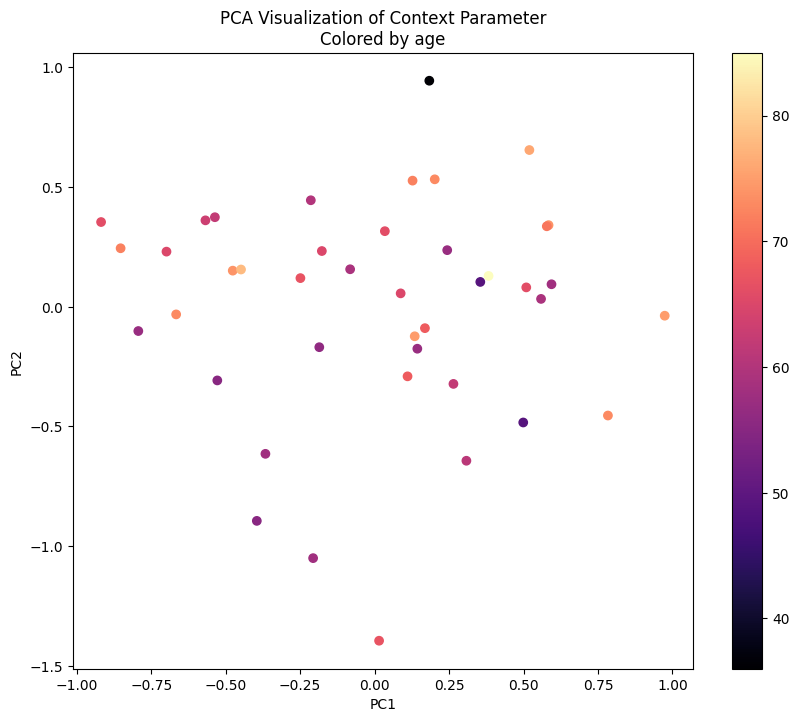

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import polars as pl

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(context_params)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=meta['age'], cmap='magma')
plt.colorbar()

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization of Context Parameter\nColored by age')
plt.show()

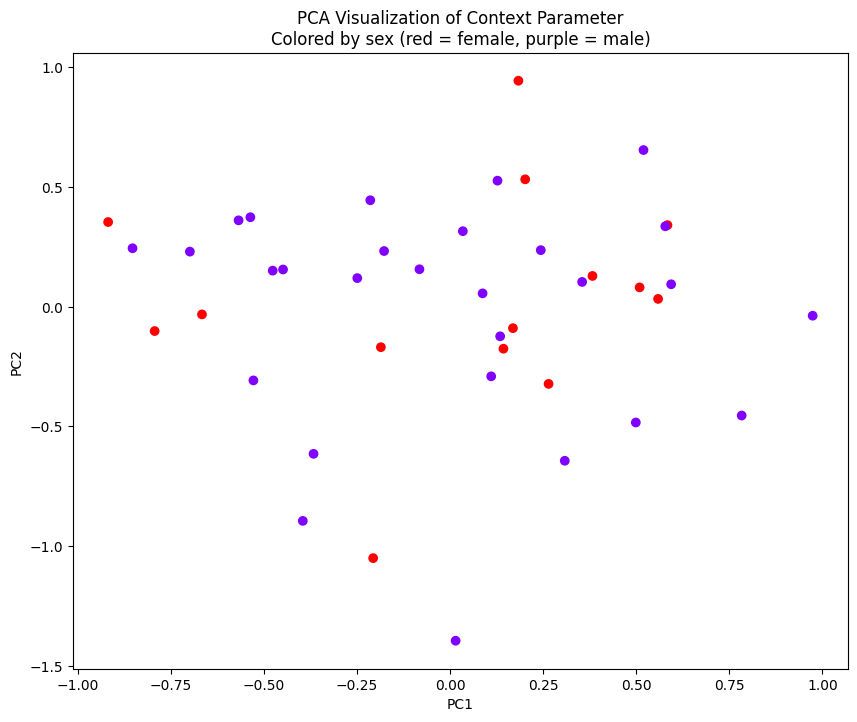

In [39]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=meta['sex'], cmap='rainbow')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization of Context Parameter\nColored by sex (red = female, purple = male)')
plt.show()

# Learned Context Neural Network with Skip Connection
Adding a skip connection from the output of the first layer to the input of the last layer. The loss is improved from learned context neural network without skip connections.

In [60]:
model = LearnedContextSkipNN(dim_in=N_FEATURES, dim_out=1, dim_hidden=300, n_hidden=3, dim_context=30, n_context=N_CONTEXT).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

full_dataset = ContextSensitiveParkinsonsDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 0.957399  [   50/ 4700]
loss: 0.778148  [  550/ 4700]
loss: 0.847468  [ 1050/ 4700]
loss: 1.159914  [ 1550/ 4700]
loss: 0.998106  [ 2050/ 4700]
loss: 0.864631  [ 2550/ 4700]
loss: 1.031244  [ 3050/ 4700]
loss: 0.743362  [ 3550/ 4700]
loss: 1.018990  [ 4050/ 4700]
loss: 1.140383  [ 4550/ 4700]
Test Error: 
 Avg loss: 1.018039 

Epoch 2
-------------------------------
loss: 0.889996  [   50/ 4700]
loss: 0.728191  [  550/ 4700]
loss: 0.816163  [ 1050/ 4700]
loss: 1.103121  [ 1550/ 4700]
loss: 0.971299  [ 2050/ 4700]
loss: 0.816142  [ 2550/ 4700]
loss: 0.990914  [ 3050/ 4700]
loss: 0.701539  [ 3550/ 4700]
loss: 0.972131  [ 4050/ 4700]
loss: 1.088089  [ 4550/ 4700]
Test Error: 
 Avg loss: 0.965975 

Epoch 3
-------------------------------
loss: 0.850251  [   50/ 4700]
loss: 0.693056  [  550/ 4700]
loss: 0.780614  [ 1050/ 4700]
loss: 1.058711  [ 1550/ 4700]
loss: 0.934814  [ 2050/ 4700]
loss: 0.779743  [ 2550/ 4700]
loss: 0.958059  [ 3050/ 4700]
